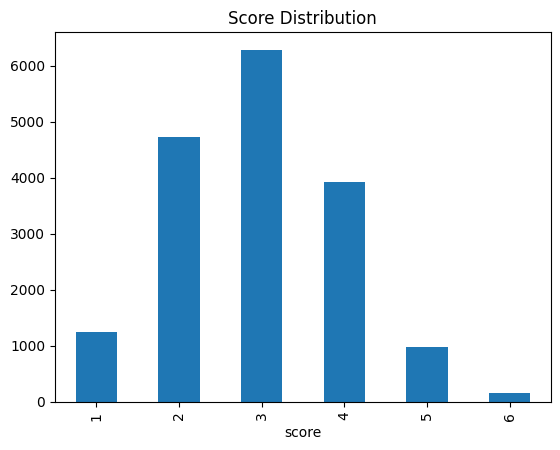

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/essay/train.csv')
df['score'].value_counts().sort_index().plot(kind='bar')
plt.title('Score Distribution')
plt.savefig('../outputs/score_dist.png')
plt.show()

In [2]:
import sys, os, warnings
sys.path.insert(0, '..')
os.chdir('..')
warnings.filterwarnings('ignore')

import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer
from src.models.essay_model import EssayScorer
from src.utils.config import load_config

cfg    = load_config('configs/config.yaml')['stage2']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

MODEL_DIR = 'outputs/models/essay/fold_1'
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = EssayScorer(MODEL_DIR, dropout=0.1)
model.regressor.load_state_dict(
    torch.load(f'{MODEL_DIR}/regressor_head.pt', map_location=device)
)
model.to(device).eval()
print("Model loaded.")

Device: cuda
Model loaded.


In [3]:
df = pd.read_csv(cfg['train_path'])

sample_essays = {}
for score in [2, 4, 6]:
    row = df[df['score'] == score].iloc[0]
    sample_essays[score] = {
        'essay_id': row['essay_id'],
        'text':     row['full_text'],
        'score':    score,
    }
    print(f"Score {score} | id: {row['essay_id']} | "
          f"words: {len(row['full_text'].split())}")

Score 2 | id: 0033037 | words: 179
Score 4 | id: 001ab80 | words: 550
Score 6 | id: 02d481d | words: 1007


In [4]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def predict_score(text: str) -> float:
    """Score one essay. Returns raw float clipped to [1,6]."""
    enc = tokenizer(
        text, max_length=cfg['max_length'],
        truncation=True, padding='max_length', return_tensors='pt'
    )
    with torch.no_grad():
        from torch.cuda.amp import autocast
        with autocast():
            _, logit = model(
                enc['input_ids'].to(device),
                enc['attention_mask'].to(device)
            )
    return float(np.clip(logit.cpu().numpy()[0], 1, 6))


def sentence_importance(essay_text: str) -> tuple:
    """Leave-one-out sentence importance.

    For each sentence: remove it, re-score the essay.
    Importance = base_score - score_without_sentence.
    Positive = sentence raises score. Negative = sentence lowers score.
    Returns (importance_dict, base_score).
    """
    sentences  = sent_tokenize(essay_text)
    base_score = predict_score(essay_text)
    print(f"  Base score: {base_score:.3f} | {len(sentences)} sentences", flush=True)

    importances = {}
    for i, sent in enumerate(sentences):
        remaining     = [s for j, s in enumerate(sentences) if j != i]
        masked_score  = predict_score(' '.join(remaining))
        importances[sent] = base_score - masked_score   # drop when removed

        if i % 5 == 0:
            print(f"  Sentence {i+1}/{len(sentences)}: "
                  f"importance={importances[sent]:+.4f}", flush=True)

    return importances, base_score

In [5]:
os.makedirs('outputs/shap_plots', exist_ok=True)
shap_results = {}

for score, info in sample_essays.items():
    print(f"\nProcessing score-{score} essay...")
    imp_dict, base = sentence_importance(info['text'])
    shap_results[score] = {
        'text':       info['text'],
        'true_score': score,
        'pred_score': base,
        'shap':       imp_dict,
    }
    vals = list(imp_dict.values())
    print(f"  Value range: {min(vals):+.4f} to {max(vals):+.4f}")

    best  = max(imp_dict, key=imp_dict.get)
    worst = min(imp_dict, key=imp_dict.get)
    print(f"  Most  helpful: [{imp_dict[best]:+.4f}] {best[:70]}...")
    print(f"  Most harmful:  [{imp_dict[worst]:+.4f}] {worst[:70]}...")


Processing score-2 essay...
  Base score: 2.184 | 7 sentences
  Sentence 1/7: importance=+0.1289
  Sentence 6/7: importance=+0.0938
  Value range: +0.0762 to +0.2529
  Most  helpful: [+0.2529] I think that the face reconizing computer would be very reliable; beca...
  Most harmful:  [+0.0762] Its would be helpful in a ways of satifying our needs and why showing ...

Processing score-4 essay...
  Base score: 4.863 | 24 sentences
  Sentence 1/24: importance=+0.1797
  Sentence 6/24: importance=+0.1367
  Sentence 11/24: importance=+0.0039
  Sentence 16/24: importance=-0.0156
  Sentence 21/24: importance=+0.0000
  Value range: -0.0156 to +0.4102
  Most  helpful: [+0.4102] Many states do not even let people drive semi-automatic cars because t...
  Most harmful:  [-0.0156] If these cars become more popular, states may pass new laws....

Processing score-6 essay...
  Base score: 4.941 | 42 sentences
  Sentence 1/42: importance=+0.0000
  Sentence 6/42: importance=-0.0039
  Sentence 11/42: impo

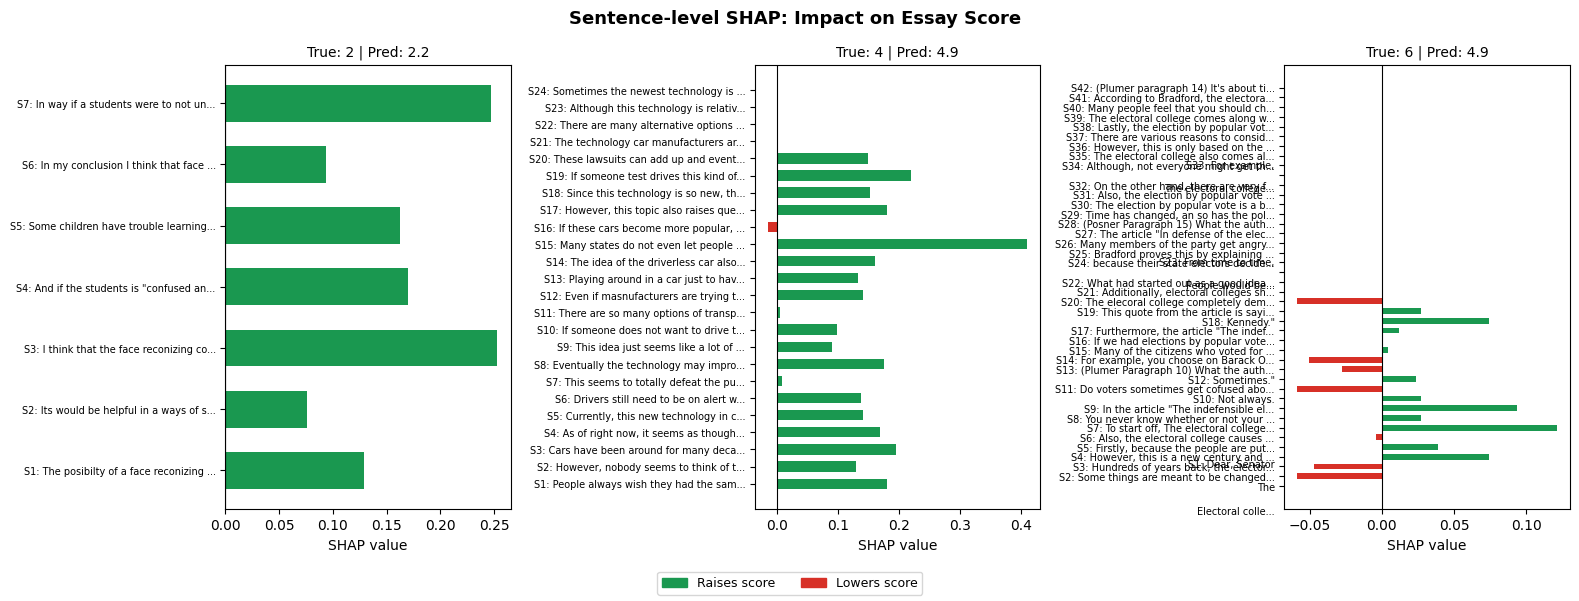

Saved: outputs/shap_plots/shap_summary_3essays.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Sentence-level SHAP: Impact on Essay Score',
             fontsize=13, fontweight='bold')

for ax, (score, result) in zip(axes, shap_results.items()):
    shap_dict = result['shap']
    sentences = list(shap_dict.keys())
    values    = np.array(list(shap_dict.values()))
    colors    = ['#d73027' if v < 0 else '#1a9850' for v in values]
    labels    = [f"S{i+1}: {s[:35]}..." if len(s) > 35
                 else f"S{i+1}: {s}"
                 for i, s in enumerate(sentences)]

    ax.barh(np.arange(len(sentences)), values,
            color=colors, edgecolor='none', height=0.6)
    ax.set_yticks(np.arange(len(sentences)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"True: {score} | Pred: {result['pred_score']:.1f}", fontsize=10)
    ax.set_xlabel('SHAP value')

green = mpatches.Patch(color='#1a9850', label='Raises score')
red   = mpatches.Patch(color='#d73027', label='Lowers score')
fig.legend(handles=[green, red], loc='lower center', ncol=2, fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
save_path = 'outputs/shap_plots/shap_summary_3essays.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

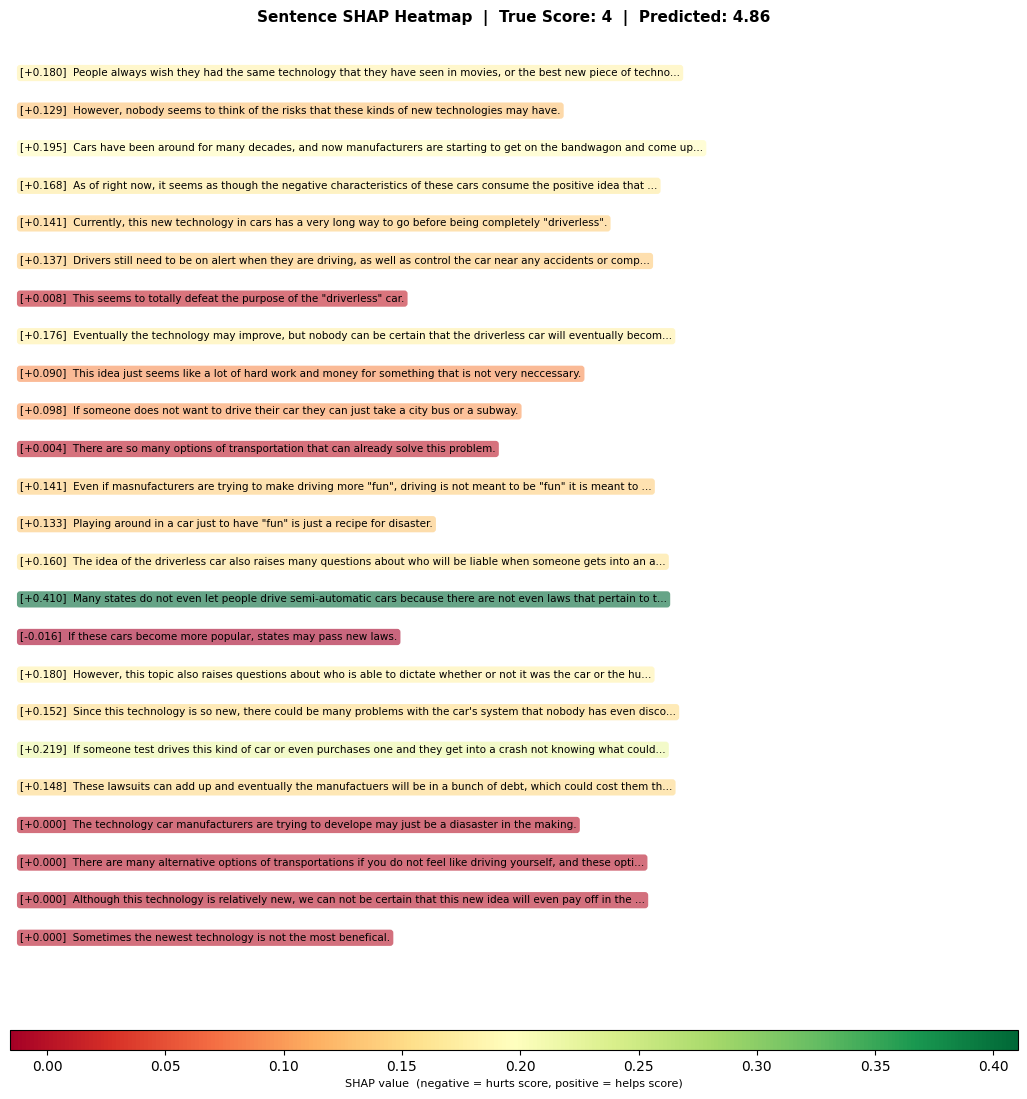

Saved: outputs/shap_plots/shap_heatmap_single_essay.png


In [7]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

showcase  = shap_results[4]
shap_dict = showcase['shap']
sentences = list(shap_dict.keys())
values    = np.array(list(shap_dict.values()))

norm = Normalize(vmin=values.min(), vmax=values.max())
cmap = cm.RdYlGn

fig, ax = plt.subplots(figsize=(13, max(5, len(sentences) * 0.55)))
ax.axis('off')

y           = 0.97
line_height = min(0.09, 0.92 / len(sentences))

for sent, val in zip(sentences, values):
    color   = cmap(norm(val))
    display = sent[:110] + '...' if len(sent) > 110 else sent
    ax.text(
        0.01, y,
        f"[{val:+.3f}]  {display}",
        transform=ax.transAxes, fontsize=7.5,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                  alpha=0.6, edgecolor='none')
    )
    y -= line_height

ax.set_title(
    f"Sentence SHAP Heatmap  |  "
    f"True Score: {showcase['true_score']}  |  "
    f"Predicted: {showcase['pred_score']:.2f}",
    fontsize=11, fontweight='bold', pad=12
)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.025, pad=0.01, aspect=50)
cbar.set_label('SHAP value  (negative = hurts score, positive = helps score)',
               fontsize=8)

save_path = 'outputs/shap_plots/shap_heatmap_single_essay.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {save_path}")